In [1]:
!pip install torch torchvision torchaudio
!pip install matplotlib
!pip install numpy
!pip install pillow
!pip install opencv-python
!pip install scipy
!pip install imageio
!pip install tqdm

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
from torchvision.datasets import CelebA
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import cv2
import imageio
from tqdm import tqdm
import scipy

In [3]:
from __future__ import print_function

import argparse
import os
import random
import torch
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML


manualSeed = 999

print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)

Random Seed:  999


In [4]:
class ImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.image_paths = sorted(os.listdir(root))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, self.image_paths[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image

In [5]:
transform = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

In [6]:
dataroot = "/kaggle/input/cardetection/car/train/images"
dataset = ImageDataset(dataroot, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [7]:
# Number of workers for dataloader
workers = 2

# Batch size during training
batch_size = 64

# Spatial size of training images. All images will be resized to this
#   size using a transformer.
image_size = 640

# Number of channels in the training images. For color images this is 3
nc = 3

# Size of feature maps in generator
ngf = 64
nz=100

# Size of feature maps in discriminator
ndf = 64

# Number of training epochs
num_epochs = 15

# Learning rate for optimizers
lr = 0.0002

# Beta1 hyperparam for Adam optimizers
beta1 = 0.5

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 1

In [8]:
class PixelNoise(nn.Module):
    def __init__(self, noise_intensity=0.1, num_pixels=100):
        super(PixelNoise, self).__init__()
        self.noise_intensity = noise_intensity  # Strength of noise
        self.num_pixels = num_pixels  # Number of pixels to modify

    def forward(self, x):
        b, c, h, w = x.shape  # Batch, Channels, Height, Width

        # Clone to avoid in-place operations
        x_modified = x.clone()

        # Apply noise to a few random pixels
        for batch in range(b):
            for i in range(self.num_pixels):
                # Pick random x, y coordinates for each batch
                x_coord = torch.randint(0, w, (1,), device=x.device).item()
                y_coord = torch.randint(0, h, (1,), device=x.device).item()

                # Generate small noise for selected pixel
                noise = torch.randn((c,), device=x.device) * self.noise_intensity

                # Modify only that pixel across all channels
                x_modified[batch, :, y_coord, x_coord] += noise

        return torch.clamp(x_modified, -1, 1)  # Keep values in range





In [9]:
# Custom weights initialization called on netG and netD
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)
    elif classname.find('add_random_pixel_noise') != -1:  # Initialize noise layer
        m.sigma = 0.1  # Set initial noise standard deviation

In [10]:
class Generator(nn.Module):
    def __init__(self, ngpu, nz, ngf, nc):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 16),
            nn.LeakyReLU(0.2, inplace=True),
            PixelNoise(num_pixels=50, noise_intensity=0.05),

            nn.ConvTranspose2d(ngf * 16, ngf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            PixelNoise(num_pixels=40, noise_intensity=0.04),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            PixelNoise(num_pixels=30, noise_intensity=0.03),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.LeakyReLU(0.2, inplace=True),
            PixelNoise(num_pixels=20, noise_intensity=0.02),

            nn.ConvTranspose2d(ngf, ngf, 3, 1, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)


In [11]:
# Create the generator
netG = Generator(ngpu,nz,ngf,nc).to(device)

# Handle multi-gpu if desired
if (device.type == 'cuda') and (ngpu > 1):
    netG = nn.DataParallel(netG, list(range(ngpu)))

# Apply the weights_init function to randomly initialize all weights
#  to mean=0, stdev=0.2.
netG.apply(weights_init)

# Print the model
print(netG)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 1024, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): PixelNoise()
    (4): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (5): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.2, inplace=True)
    (7): PixelNoise()
    (8): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): PixelNoise()
    (12): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [12]:
class Discriminator(nn.Module):
    def __init__(self, ngpu, nc=3, ndf=64):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

In [13]:
# Create the Discriminator
netD = Discriminator(ngpu).to(device)

# Handle multi-gpu if desired
if (device.type == 'cuda') and (ngpu > 1):
    netD = nn.DataParallel(netD, list(range(ngpu)))

# Apply the weights_init function to randomly initialize all weights
#  to mean=0, stdev=0.2.
netD.apply(weights_init)

# Print the model
print(netD)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)


In [14]:
# Initialize BCELoss function
criterion = nn.BCELoss()

# Create batch of latent vectors that we will use to visualize
#  the progression of the generator
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# Establish convention for real and fake labels during training
real_label = 1
fake_label = 0

# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

In [15]:
real_cpu, *_ = next(iter(dataloader))  # Unpack only the first value

In [16]:
real_cpu.dim()

3

In [17]:
if real_cpu.dim() == 3:  # Shape is [channels, height, width]
    real_cpu = real_cpu.unsqueeze(0)  # Add batch dimension: [1, channels, height, width]

print(f"Shape of real_cpu after unsqueeze: {real_cpu.shape}")

Shape of real_cpu after unsqueeze: torch.Size([1, 3, 640, 640])


In [18]:
data = next(iter(dataloader))
print(len(data))
print(type(data))

64
<class 'torch.Tensor'>


In [19]:
noise = torch.randn(batch_size, nz, 1, 1, device=device)
fake = netG(noise)

In [20]:
noise.size()

torch.Size([64, 100, 1, 1])

In [21]:
img_list = []
G_losses = []
D_losses = []
iters = 0

print("Starting Training Loop...")
for epoch in range(num_epochs):
    for i, data in enumerate(dataloader, 0):
        ############################
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        ############################
        netD.zero_grad()
        real_cpu = data[0].to(device)
        # Ensure the input has 4 dimensions (batch, channels, height, width)
        if real_cpu.ndim == 3:
            real_cpu = real_cpu.unsqueeze(0)
        b_size = real_cpu.size(0)

        # Forward pass real batch through D.
        output_real = netD(real_cpu)
        # Create a target tensor with the same shape as output_real:
        target_real = torch.full_like(output_real, real_label, device=device)
        errD_real = criterion(output_real, target_real)
        errD_real.backward()
        D_x = output_real.mean().item()

        ## Train with all-fake batch
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        output_fake = netD(fake.detach())
        target_fake = torch.full_like(output_fake, fake_label, device=device)
        errD_fake = criterion(output_fake, target_fake)
        errD_fake.backward()
        D_G_z1 = output_fake.mean().item()
        errD = errD_real + errD_fake
        optimizerD.step()

        ############################
        # (2) Update G network: maximize log(D(G(z)))
        ############################
        netG.zero_grad()
        output_fake_forG = netD(fake)
        target_forG = torch.full_like(output_fake_forG, real_label, device=device)
        errG = criterion(output_fake_forG, target_forG)
        errG.backward()
        D_G_z2 = output_fake_forG.mean().item()
        optimizerG.step()

        # Print training stats every 50 mini-batches
        if i % 50 == 0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                  % (epoch, num_epochs, i, len(dataloader),
                     errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Check how the generator is doing by saving G's output on fixed_noise
        if (iters % 500 == 0) or ((epoch == num_epochs-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake_images = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake_images, padding=2, normalize=True))
        iters += 1

Starting Training Loop...
[0/15][0/56]	Loss_D: 1.8337	Loss_G: 3.2761	D(x): 0.3267	D(G(z)): 0.3442 / 0.0943
[0/15][50/56]	Loss_D: 0.2126	Loss_G: 4.6628	D(x): 0.9094	D(G(z)): 0.1013 / 0.0177
[1/15][0/56]	Loss_D: 0.4649	Loss_G: 4.4661	D(x): 0.8206	D(G(z)): 0.1502 / 0.0160
[1/15][50/56]	Loss_D: 0.1600	Loss_G: 4.6004	D(x): 0.9187	D(G(z)): 0.0623 / 0.0122
[2/15][0/56]	Loss_D: 0.4982	Loss_G: 6.3231	D(x): 0.9318	D(G(z)): 0.2877 / 0.0138
[2/15][50/56]	Loss_D: 0.1795	Loss_G: 6.6360	D(x): 0.9344	D(G(z)): 0.0938 / 0.0017
[3/15][0/56]	Loss_D: 0.2038	Loss_G: 4.9288	D(x): 0.8897	D(G(z)): 0.0709 / 0.0093
[3/15][50/56]	Loss_D: 0.0598	Loss_G: 5.1358	D(x): 0.9792	D(G(z)): 0.0375 / 0.0072
[4/15][0/56]	Loss_D: 0.0600	Loss_G: 5.6341	D(x): 0.9642	D(G(z)): 0.0228 / 0.0047
[4/15][50/56]	Loss_D: 0.0470	Loss_G: 5.1989	D(x): 0.9751	D(G(z)): 0.0212 / 0.0060
[5/15][0/56]	Loss_D: 0.0534	Loss_G: 5.5608	D(x): 0.9874	D(G(z)): 0.0386 / 0.0046
[5/15][50/56]	Loss_D: 0.0330	Loss_G: 5.2543	D(x): 0.9820	D(G(z)): 0.0146 / 0.0

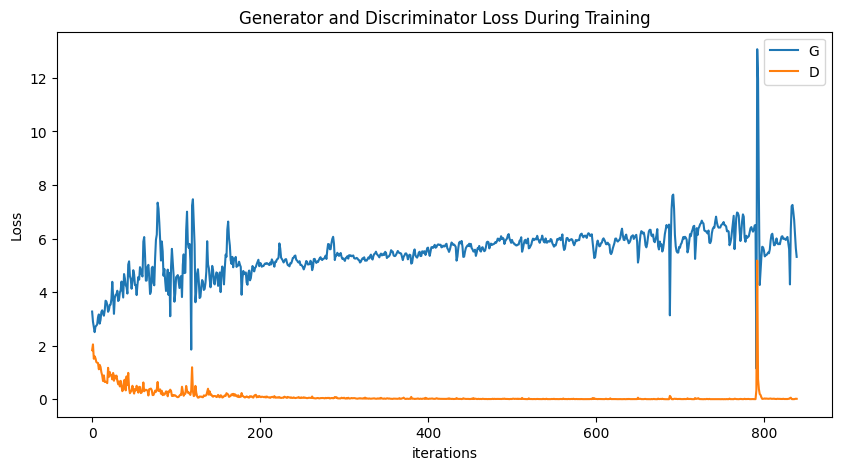

In [22]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

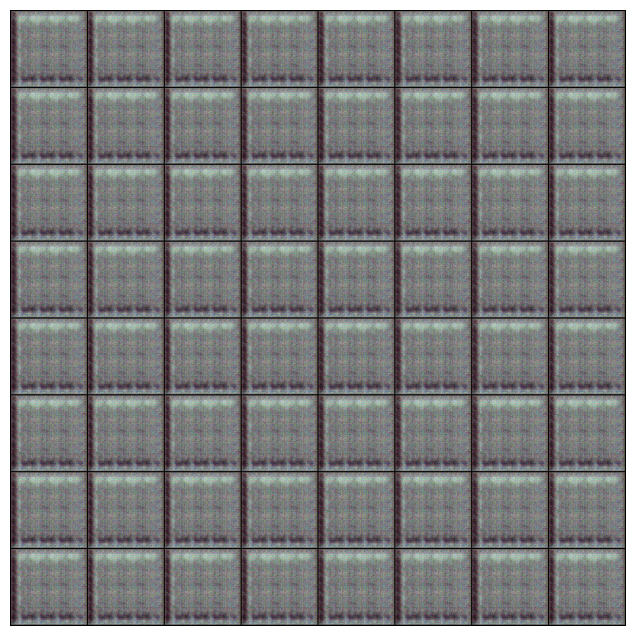

In [23]:
#%%capture
fig = plt.figure(figsize=(8,8))
plt.axis("off")
ims = [[plt.imshow(np.transpose(i,(1,2,0)), animated=True)] for i in img_list]
ani = animation.ArtistAnimation(fig, ims, interval=1000, repeat_delay=1000, blit=True)

HTML(ani.to_jshtml())

In [24]:
def add_noise_to_image(image, device, sigma=0.1, num_pixels=100):
    """
    Vectorized version: Adds noise to selected pixels instaneously 
    without using a slow Python for-loop.
    """
    b, c, h, w = image.shape
    image = image.to(device)
    
    # Clone to avoid in-place errors
    noisy_image = image.clone()
    
    # Total number of spatial pixels per channel
    total_pixels = h * w
    
    # 1. Generate random indices (locations) ONCE per batch item
    # We flatten the (H, W) grid to a 1D array of size H*W to pick indices easily
    for batch_idx in range(b):
        # Get random unique indices
        flat_indices = torch.randperm(total_pixels, device=device)[:num_pixels]
        
        # 2. Create the noise vector for these specific pixels
        noise = torch.randn((c, num_pixels), device=device) * sigma
        
        # 3. Flatten the image spatially to (Channels, H*W) to apply noise using indices
        # View as (C, H*W)
        flat_img = noisy_image[batch_idx].view(c, -1)
        
        # Add noise to the selected indices
        # We iterate channels effectively by broadcasting or simple looping (fast for c=3)
        for ch in range(c):
            flat_img[ch, flat_indices] += noise[ch]
            
    return torch.clamp(noisy_image, -1, 1)

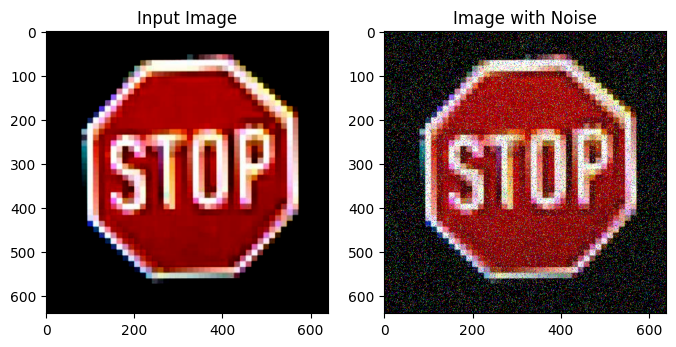

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Load a real image
real_image_path = "/kaggle/input/cardetection/car/test/images/00014_00003_00007_png.rf.4a4b5bfabfe079ec34b2bf1142a0461b.jpg"  # Provide your real image path
real_image = Image.open(real_image_path).convert("RGB")
real_image = transform(real_image).unsqueeze(0).to(device)  # Transform and move to device

# Apply noise to selected pixels only (Fix: Removed netG argument)
noisy_image = add_noise_to_image(real_image, device, sigma=3, num_pixels=80000)

# Convert images to numpy format for visualization
real_np = np.transpose(real_image[0].cpu().numpy(), (1, 2, 0))
noisy_np = np.transpose(noisy_image[0].cpu().numpy(), (1, 2, 0))

# Visualize results
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("Input Image")
plt.imshow(real_np)
plt.subplot(1, 2, 2)
plt.title("Image with Noise")
plt.imshow(noisy_np)
plt.show()



In [26]:
test_dataroot="/kaggle/input/cardetection/car/test/images"
test_dataset = ImageDataset(test_dataroot, transform=transform)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=True, num_workers=2)

In [27]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

# 1. Define input and output paths for both sets
dataset_paths = {
    "train": "/kaggle/input/cardetection/car/train/images",
    "test":  "/kaggle/input/cardetection/car/test/images"
}

base_output_dir = "/kaggle/working/processed_data"

# 2. settings for INCREASED noise intensity
# Previous: sigma=3, num_pixels=80000
# New: sigma=6 (stronger variance), num_pixels=150000 (more coverage)
NOISE_SIGMA = 6
NOISE_PIXELS = 150000

for split, input_dir in dataset_paths.items():
    # Create specific output folder (e.g., .../noisy_train)
    output_dir = os.path.join(base_output_dir, f"noisy_{split}")
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"🚀 Processing {split} images from: {input_dir}")
    print(f"📂 Saving to: {output_dir}")

    # Loop through images
    for fname in tqdm(os.listdir(input_dir)):
        if fname.lower().endswith((".png", ".jpg", ".jpeg")):
            img_path = os.path.join(input_dir, fname)

            try:
                # Load and preprocess image
                img = Image.open(img_path).convert("RGB")
                img_tensor = transform(img).unsqueeze(0).to(device)

                # Add noise with INCREASED intensity parameters
                noisy_tensor = add_noise_to_image(
                    img_tensor, 
                    device, 
                    sigma=NOISE_SIGMA, 
                    num_pixels=NOISE_PIXELS
                )

                # Convert back to numpy for saving
                noisy_np = noisy_tensor[0].detach().cpu().numpy()
                noisy_np = np.transpose(noisy_np, (1, 2, 0))

                # De-normalize from [-1,1] to [0,255]
                noisy_np = ((noisy_np + 1) / 2 * 255).astype(np.uint8)

                # Save noisy image (keeping original filename for easier matching later)
                out_path = os.path.join(output_dir, f"noisy_{fname}")
                Image.fromarray(noisy_np).save(out_path)
                
            except Exception as e:
                print(f"⚠️ Error processing {fname}: {e}")

    print(f"✅ All {split} images processed.\n")

print("🎉 pipeline complete.")

🚀 Processing train images from: /kaggle/input/cardetection/car/train/images
📂 Saving to: /kaggle/working/processed_data/noisy_train


100%|██████████| 3530/3530 [01:38<00:00, 35.98it/s]


✅ All train images processed.

🚀 Processing test images from: /kaggle/input/cardetection/car/test/images
📂 Saving to: /kaggle/working/processed_data/noisy_test


100%|██████████| 638/638 [00:21<00:00, 29.81it/s]

✅ All test images processed.

🎉 pipeline complete.


In [28]:
import shutil

# Zip the noisy images folder
shutil.make_archive("/kaggle/working/noisy_images", 'zip', "/kaggle/working/noisy_images")

print("✅ noisy_images.zip created in /kaggle/working/")
print("Go to the right panel → 'Output' → 'Data' → download noisy_images.zip")


✅ noisy_images.zip created in /kaggle/working/
Go to the right panel → 'Output' → 'Data' → download noisy_images.zip
